# BASTION: U.S. Airline Traffic Example

This notebook applies BASTION to **monthly U.S. international airline passenger counts (2003-2023)**.  It is based on Section 6.1 and Appendix D of:

> Cho, J. B. & Matteson, D. S. (2026). *BASTION: A Bayesian Framework for Trend and Seasonality Decomposition.* arXiv:2601.18052.

## Why this dataset?

The airline traffic series has a textbook structure:
- A **long-term upward trend** in international travel.
- A pronounced **annual seasonality** (peak July/August, trough January/February).
- A sharp **structural break** in early 2020 caused by COVID-19 travel restrictions.

BASTION's horseshoe prior on second differences allows the trend to adapt sharply at the COVID-19 break while remaining smooth elsewhere.  As the paper notes (Section 6.1):

> *'BASTION provides a smooth yet adaptive trend, capturing the abrupt COVID-19 drop while preserving overall structure.'*

## What this notebook covers

1. Load and explore the dataset.
2. Fit BASTION with an annual seasonal component (K = 12).
3. Visualise the signal with 95% credible bands.
4. Full decomposition — trend, seasonality, remainder.
5. Simulation-average metrics from the paper + in-sample fit statistics.

In [1]:
import os, sys, warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_DIR  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
OUTPUT_DIR   = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

sys.path.insert(0, PROJECT_DIR)
from pybastion import fit_BASTION
from pybastion.datasets import load_airtraffic as _load_raw

# ── QUICK_MODE ──────────────────────────────────────────────────────
# True  → short MCMC chain, runs in ~30 s (suitable for a quick demo).
# False → full MCMC chain, runs in ~30-60 min.
QUICK_MODE = True

if QUICK_MODE:
    nsave, nburn, nskip, nchains = 200, 300, 1, 1
else:
    nsave, nburn, nskip, nchains = 2000, 5000, 4, 2

nstot = nburn + (nskip + 1) * nsave
print(f'pybastion loaded from: {PROJECT_DIR}')
print(f'QUICK_MODE={QUICK_MODE}: {nstot} total MCMC steps per chain')
print(f'  nsave={nsave}, nburn={nburn}, nskip={nskip}, nchains={nchains}')

pybastion loaded from: /media/daniel/Extreme SSD/Projects/pyBASTION
QUICK_MODE=True: 700 total MCMC steps per chain
  nsave=200, nburn=300, nskip=1, nchains=1


## 1. Load and Explore the Data

Monthly passenger counts (millions) for U.S. international routes, sourced from Kaggle (Yan, 2023).  The dataset is bundled with `pybastion` via `load_airtraffic()`.

Observations : 249 monthly records
Date range   : 2003-01-01 to 2023-09-01
Pax range    : 0.1 to 12.4


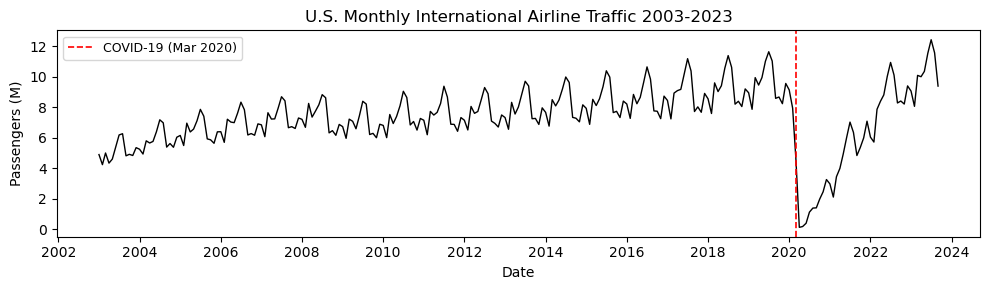

In [2]:
def load_airtraffic():
    df = _load_raw()
    df['date'] = pd.to_datetime(
        df['Year'].astype(int).astype(str) + '-'
        + df['Month'].astype(int).astype(str).str.zfill(2) + '-01')
    return df.rename(columns={'Int_Pax': 'pax'})[['date', 'pax']].reset_index(drop=True)

air = load_airtraffic()
print(f'Observations : {len(air)} monthly records')
print(f'Date range   : {air["date"].min().date()} to {air["date"].max().date()}')
print(f'Pax range    : {air["pax"].min():,.1f} to {air["pax"].max():,.1f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(air['date'], air['pax'], linewidth=1.0, color='black')
ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--',
           linewidth=1.2, label='COVID-19 (Mar 2020)')
ax.set_xlabel('Date'); ax.set_ylabel('Passengers (M)')
ax.set_title('U.S. Monthly International Airline Traffic 2003-2023')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 2. Fit BASTION

We specify a single annual seasonal component (`K = 12`).  Outlier detection is enabled to capture anomalous months.

| Parameter | Quick mode | Full mode | Meaning |
|-----------|------------|-----------|--------|
| `Ks` | `[12]` | `[12]` | Annual seasonality (monthly data) |
| `Outlier` | `True` | `True` | Horseshoe+ outlier component |
| `nsave` | 200 | 2 000 | Saved draws per chain |
| `nburn` | 300 | 5 000 | Burn-in |
| `nskip` | 1 | 4 | Thinning interval |
| `nchains` | 1 | 2 | Independent chains |

Toggle `QUICK_MODE` in the imports cell to switch.

In [3]:
result  = fit_BASTION(
    air['pax'].values,
    Ks=[12],
    Outlier=True,
    cl=0.95,
    obsSV='const',
    nsave=nsave,
    nburn=nburn,
    nskip=nskip,
    nchains=nchains,
    seed=40,
)
summary = result['summary']
print('Estimated components:', [k for k in summary if k.endswith('_sum')])

Chain 1


MCMC:   0%|          | 0/700 [00:00<?, ?it/s]

MCMC:   1%|          | 8/700 [00:00<00:08, 77.21it/s]

MCMC:   2%|▏         | 16/700 [00:00<00:09, 75.60it/s]

MCMC:   3%|▎         | 24/700 [00:00<00:09, 69.65it/s]

...

MCMC:  97%|█████████▋| 680/700 [00:09<00:00, 73.64it/s]

MCMC:  98%|█████████▊| 688/700 [00:09<00:00, 73.83it/s]

MCMC:  99%|█████████▉| 696/700 [00:09<00:00, 73.06it/s]

MCMC: 100%|██████████| 700/700 [00:09<00:00, 71.80it/s]

Estimated components: ['Trend_sum', 'Seasonal12_sum', 'Outlier_sum', 'Signal_sum']


## 3. Signal: Trend + Seasonality

The 2016-2023 window makes the COVID-19 structural break visible.  Black = posterior mean signal; red = trend alone; grey = 95% credible region.

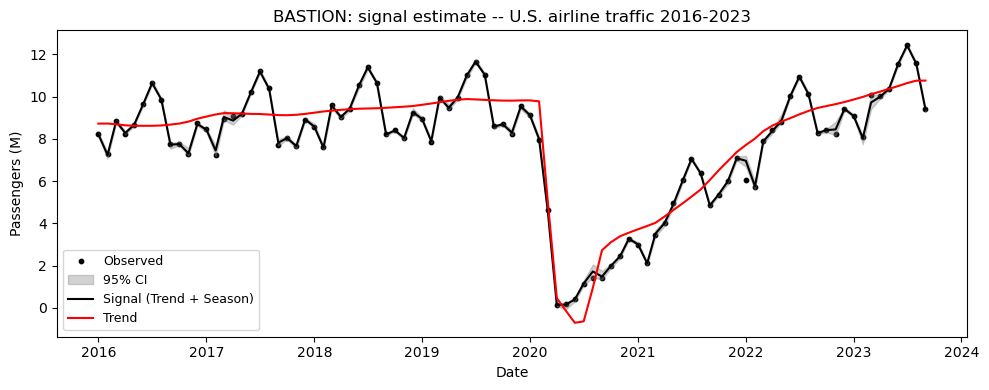

In [4]:
mask        = air['date'] >= '2016-01-01'
dates_sub   = air['date'].values[mask]
pax_sub     = air['pax'].values[mask]
idx         = np.where(mask)[0]

trend_mean  = np.asarray(summary['Trend_sum']['Mean']).ravel()[idx]
trend_lo    = np.asarray(summary['Trend_sum']['CR_lower']).ravel()[idx]
trend_hi    = np.asarray(summary['Trend_sum']['CR_upper']).ravel()[idx]
signal_mean = np.asarray(summary['Signal_sum']['Mean']).ravel()[idx]
signal_lo   = np.asarray(summary['Signal_sum']['CR_lower']).ravel()[idx]
signal_hi   = np.asarray(summary['Signal_sum']['CR_upper']).ravel()[idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(dates_sub, pax_sub, s=10, color='black', zorder=1, label='Observed')
ax.fill_between(dates_sub, signal_lo, signal_hi, color='grey', alpha=0.35, zorder=2,
                label='95% CI')
ax.plot(dates_sub, signal_mean, linewidth=1.5, color='black', zorder=3,
        label='Signal (Trend + Season)')
ax.plot(dates_sub, trend_mean,  linewidth=1.5, color='red',   zorder=4,
        label='Trend')
ax.set_xlabel('Date'); ax.set_ylabel('Passengers (M)')
ax.set_title('BASTION: signal estimate -- U.S. airline traffic 2016-2023')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'airtraffic_signal.pdf'), dpi=150,
            bbox_inches='tight')
plt.show()

## 4. Full Decomposition

Four panels over the full 2003-2023 series:
**Observed data** with signal overlaid · **Trend** · **Seasonality** (period 12) · **Remainder**.

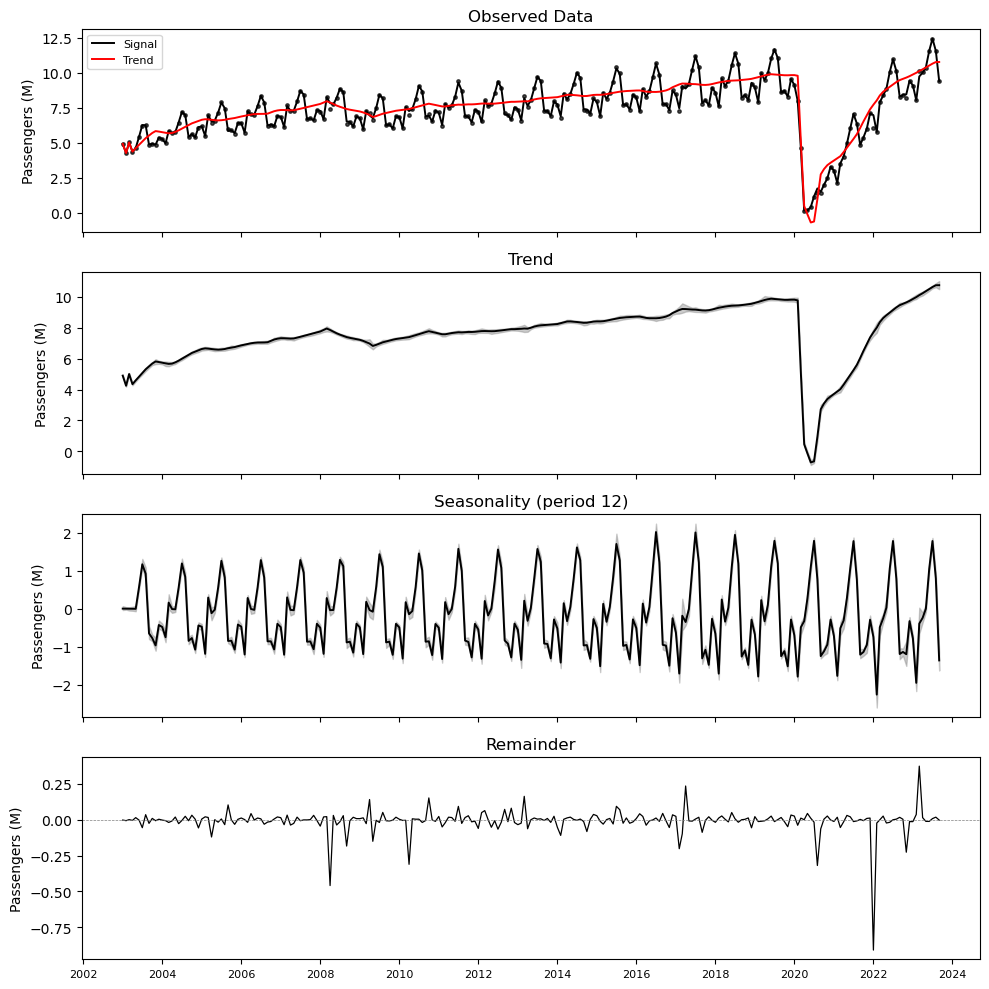

In [5]:
dates = air['date'].values
pax   = air['pax'].values

trend_m_all  = np.asarray(summary['Trend_sum']['Mean']).ravel()
trend_lo_all = np.asarray(summary['Trend_sum']['CR_lower']).ravel()
trend_hi_all = np.asarray(summary['Trend_sum']['CR_upper']).ravel()
signal_all   = np.asarray(summary['Signal_sum']['Mean']).ravel()
s12_mean     = np.asarray(summary['Seasonal12_sum']['Mean']).ravel()
s12_lo       = np.asarray(summary['Seasonal12_sum']['CR_lower']).ravel()
s12_hi       = np.asarray(summary['Seasonal12_sum']['CR_upper']).ravel()
remainder    = pax - signal_all

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

ax = axes[0]
ax.scatter(dates, pax, s=6, color='black', zorder=2, alpha=0.7)
ax.plot(dates, signal_all,  linewidth=1.4, color='black', zorder=3, label='Signal')
ax.plot(dates, trend_m_all, linewidth=1.4, color='red',   zorder=4, label='Trend')
ax.set_title('Observed Data'); ax.set_ylabel('Passengers (M)'); ax.legend(fontsize=8)

ax = axes[1]
ax.fill_between(dates, trend_lo_all, trend_hi_all, color='grey', alpha=0.4)
ax.plot(dates, trend_m_all, linewidth=1.4, color='black')
ax.set_title('Trend'); ax.set_ylabel('Passengers (M)')

ax = axes[2]
ax.fill_between(dates, s12_lo, s12_hi, color='grey', alpha=0.4)
ax.plot(dates, s12_mean, linewidth=1.4, color='black')
ax.set_title('Seasonality (period 12)'); ax.set_ylabel('Passengers (M)')

ax = axes[3]
ax.plot(dates, remainder, linewidth=0.9, color='black')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.set_title('Remainder'); ax.set_ylabel('Passengers (M)')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', labelsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'airtraffic_decomposition.pdf'), dpi=150,
            bbox_inches='tight')
plt.show()

## 5. Metrics

### 5a. Simulation-average benchmarks (Cho & Matteson 2026, Tables 2 & 3)

The values below are from the **DGP 4** simulation scenario (piecewise-linear trend, two seasonal components, stochastic volatility, outliers) — the configuration closest to this application.  These numbers come from the paper; competitor methods cannot be run via `pybastion`.

| Method | Signal MSE | Trend MSE | Seasonal MSE |
|--------|------------|-----------|-------------|
| TBATS  | 11.829 | 11.111 | 5.364 |
| MSTL   | 11.430 | 12.328 | 3.045 |
| STR    | 20.548 | 13.431 | 11.358 |
| **BASTION** | **2.877** | **5.210** | **2.562** |

| Component | STR coverage | BASTION coverage |
|---|---|---|
| Signal | 0.679 | **0.981** |
| Trend | 0.668 | **0.939** |
| Seasonality | 0.623 | **0.999** |

*Source: Tables 2 & 3, DGP 4 in Cho & Matteson (2026).*

### 5b. In-sample fit statistics — this run

Since no ground truth is available for real data, the table below reports in-sample statistics computed from the current BASTION fit.  `Signal = Trend + Seasonality` (the outlier component is counted in the remainder).

In [6]:
R2 = float(1 - np.var(remainder) / np.var(pax))
rmse = float(np.sqrt(np.mean(remainder ** 2)))
trend_range  = float(trend_m_all.max() - trend_m_all.min())
s12_range    = float(s12_mean.max() - s12_mean.min())
pct_var_trend  = float(np.var(trend_m_all) / np.var(pax) * 100)
pct_var_season = float(np.var(s12_mean)    / np.var(pax) * 100)

fit_stats = pd.DataFrame(
    {
        'Statistic': [
            'Signal R² (in-sample)',
            'Remainder RMSE',
            'Trend: peak-to-trough range [M pax]',
            'Seasonality: peak-to-trough range [M pax]',
            'Trend: share of total variance',
            'Seasonality: share of total variance',
        ],
        'Value': [
            f'{R2:.1%}',
            f'{rmse:.3f}',
            f'{trend_range:.3f}',
            f'{s12_range:.3f}',
            f'{pct_var_trend:.1f}%',
            f'{pct_var_season:.1f}%',
        ],
    }
).set_index('Statistic')
print('In-sample fit statistics -- this run')
print(fit_stats.to_string())
print()
print('R² = 1 - Var(remainder) / Var(y); Signal = Trend + Seasonality.')

In-sample fit statistics -- this run
                                            Value
Statistic                                        
Signal R² (in-sample)                       99.8%
Remainder RMSE                              0.087
Trend: peak-to-trough range [M pax]        11.468
Seasonality: peak-to-trough range [M pax]   4.287
Trend: share of total variance              84.5%
Seasonality: share of total variance        21.0%

R² = 1 - Var(remainder) / Var(y); Signal = Trend + Seasonality.
